
CART Model Metrics:
  Accuracy: 0.7922077922077922
  Precision: 0.7446808510638298
  Recall: 0.6363636363636364
  F1-Measure: 0.6862745098039216

C4.5 Model Metrics:
  Accuracy: 0.7857142857142857
  Precision: 0.7037037037037037
  Recall: 0.6909090909090909
  F1-Measure: 0.6972477064220184

Naive Bayes Model Metrics:
  Accuracy: 0.7662337662337663
  Precision: 0.6610169491525424
  Recall: 0.7090909090909091
  F1-Measure: 0.6842105263157895

Random Forest Model Metrics:
  Accuracy: 0.7662337662337663
  Precision: 0.6862745098039216
  Recall: 0.6363636363636364
  F1-Measure: 0.660377358490566

XGBoost Model Metrics:
  Accuracy: 0.7077922077922078
  Precision: 0.5806451612903226
  Recall: 0.6545454545454545
  F1-Measure: 0.6153846153846153

K-Fold Cross-Validation Results:
CART: Mean Accuracy = 0.7298, Std Dev = 0.0481
C4.5: Mean Accuracy = 0.7281, Std Dev = 0.0415
Naive Bayes: Mean Accuracy = 0.7363, Std Dev = 0.0357
Random Forest: Mean Accuracy = 0.7671, Std Dev = 0.0262
XGBoost: Mean 

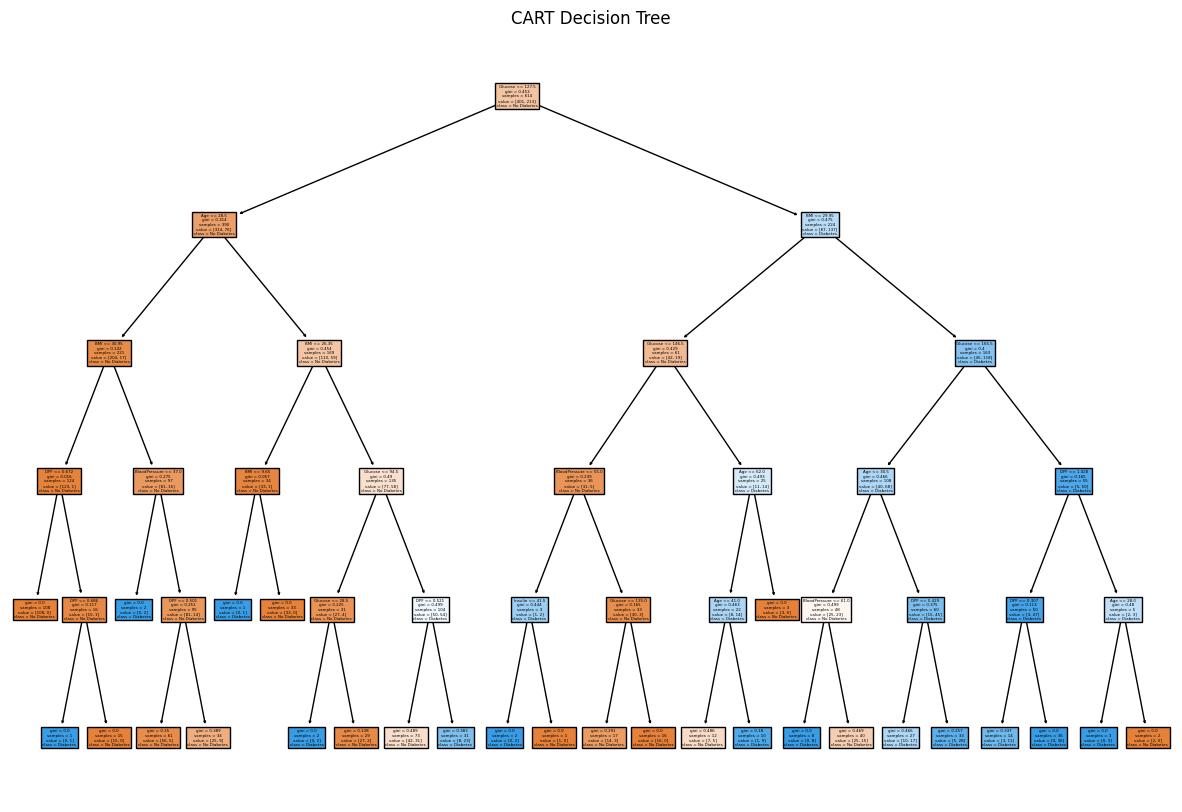

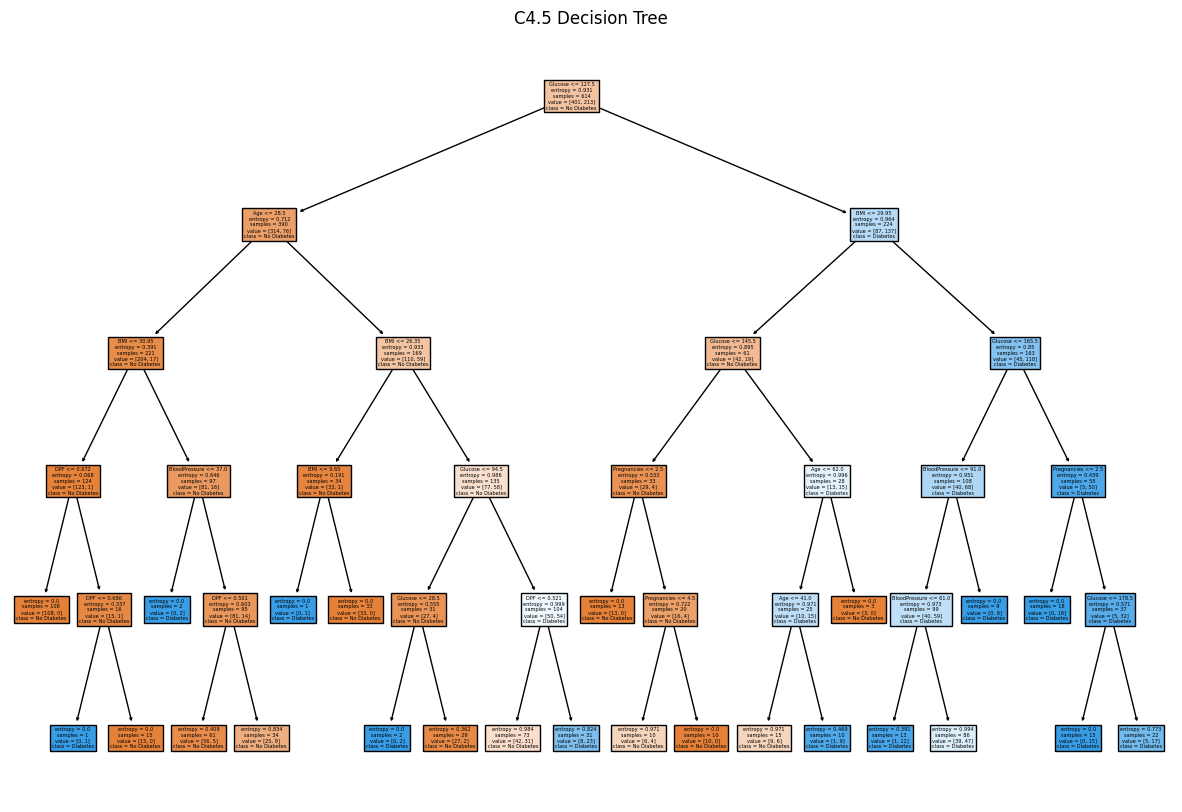

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Load dataset from the Kaggle input directory
dataset = pd.read_csv('/kaggle/input/decision-tree/Dataset.csv')

# Split the data >> 20 percent test data and 80 percent train data
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

# Separate features and target
X_train = train_data.drop(columns=['Outcome'])
y_train = train_data['Outcome']
X_test = test_data.drop(columns=['Outcome'])
y_test = test_data['Outcome']

# Model 1: CART
cart_model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
cart_model.fit(X_train, y_train)

# Model 2: C4.5 Approximation
c45_model = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
c45_model.fit(X_train, y_train)

# Model 3: Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Model 4: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Model 5: XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Testing and calculating metrics
models = {
    "CART": cart_model,
    "C4.5": c45_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}

for model_name, model in models.items():
    predictions = model.predict(X_test)
    print(f"\n{model_name} Model Metrics:")
    print("  Accuracy:", accuracy_score(y_test, predictions))
    print("  Precision:", precision_score(y_test, predictions))
    print("  Recall:", recall_score(y_test, predictions))
    print("  F1-Measure:", f1_score(y_test, predictions))

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("\nK-Fold Cross-Validation Results:")

for model_name, model in models.items():
    if model_name == "Naive Bayes":  # Handle Naive Bayes separately due to probability scaling
        kfold_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    else:
        kfold_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    print(f"{model_name}: Mean Accuracy = {kfold_scores.mean():.4f}, Std Dev = {kfold_scores.std():.4f}")

# Plotting CART Tree
plt.figure(figsize=(15, 10))
plot_tree(cart_model, filled=True, feature_names=X_train.columns, class_names=["No Diabetes", "Diabetes"])
plt.title("CART Decision Tree")
plt.show()

# Plotting C4.5 Tree
plt.figure(figsize=(15, 10))
plot_tree(c45_model, filled=True, feature_names=X_train.columns, class_names=["No Diabetes", "Diabetes"])
plt.title("C4.5 Decision Tree")
plt.show()

